In [4]:
import numpy as np
import matplotlib.pyplot as plt

In [24]:
def deriv_sim(f,x):
    df = np.zeros_like(f)
    for i in range(1,len(x)-1):
        df[i] = (f[i+1]-f[i-1])/(x[i+1]-x[i-1])
    df[0] = 0.5*(-3*f[0] + 4*f[1] - f[2])/(x[1]-x[0])
    df[-1] = 0.5*(3*f[-1] - 4*f[-2] + f[-3])/(x[-1]-x[-2])
    return df


Consideremos un potencial
$$
v=\frac{1}{r⁴}
$$

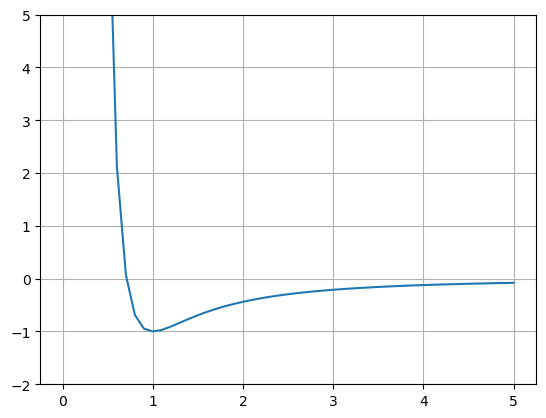

In [25]:
h = 0.1
x = np.arange(1e-3,5+h,h)
y = 1/x**4 - 2/x**2

plt.plot(x,y)
plt.ylim([-2,5])
plt.grid()
plt.show()

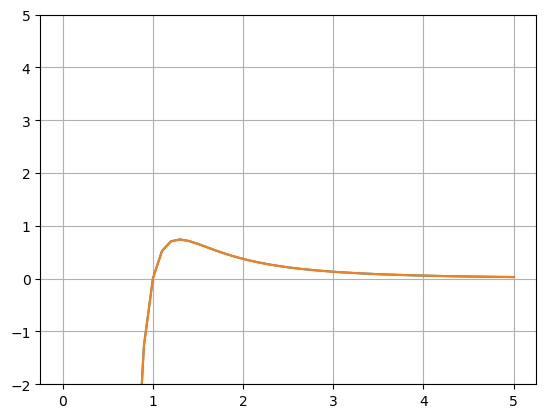

In [26]:
# Cómo hago cálculos sobre esto?, tomamos la función V
dy = -4/x**5 + 4/x**3
dy_num = deriv_sim(y,x)

plt.plot(x,dy, label=r'f´ analítica')
plt.plot(x,dy, label=r'f´ numérica')
plt.ylim([-2,5])
plt.grid()
plt.show()

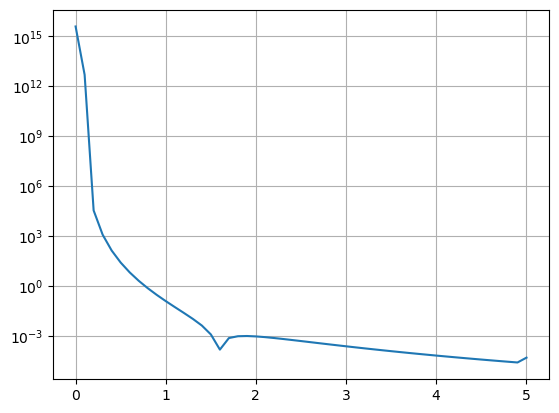

In [27]:
error = abs(dy-dy_num)

#Esta no es la mejor manera de graficarlo, semilog ocupa logaritmos
#plt.plot(x, error)
#plt.ylim([0,1])

plt.semilogy(x, error)

plt.grid()
plt.show()

In [ ]:
########Aqui va texto

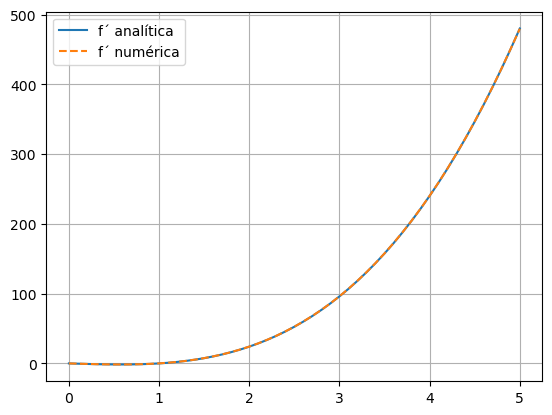

In [28]:
z = x**4 - 2*x**2
dz = 4*x**3 - 4*x
dz_num = deriv_sim(z,x)

plt.plot(x,dz, label=r'f´ analítica')
plt.plot(x,dz_num,'--', label=r'f´ numérica')
plt.legend()
plt.grid()
plt.show()

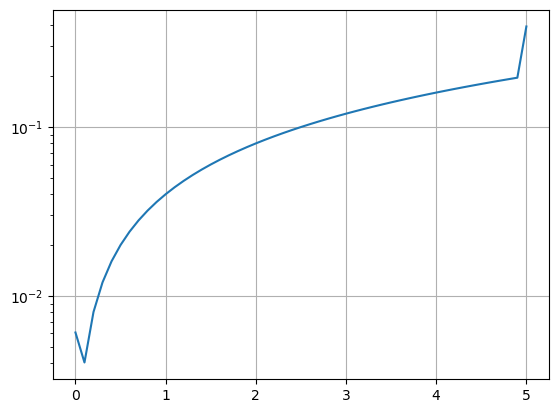

In [30]:
error_z = abs(dz-dz_num)

plt.semilogy(x,error_z)
plt.grid()
plt.show()

In [ ]:
# 
z1 = x**4
z2 = -2*x**2


In [ ]:
#Calculamos nuevamente el error


_______________


## Resolviendo por partes

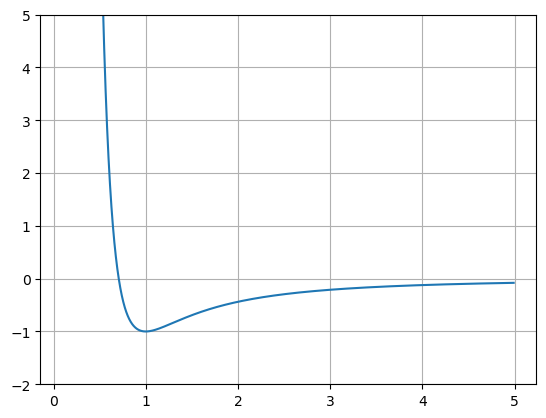

In [37]:
h1 = 1e-4
pt_empalme = 1
pt_empalme_2 = 2
x1 = np.arange(0.1,pt_empalme,h1)
h2 = 1e-3
x2 = np.arange(pt_empalme,pt_empalme_2,h2)
h3 = 1e-2
x3 = np.arange(pt_empalme_2,5,h3)

x = np.concatenate((x1,x2,x3))
y = 1/x**4 - 2/x**2

plt.plot(x,y)
plt.ylim([-2,5])
plt.grid()
plt.show()


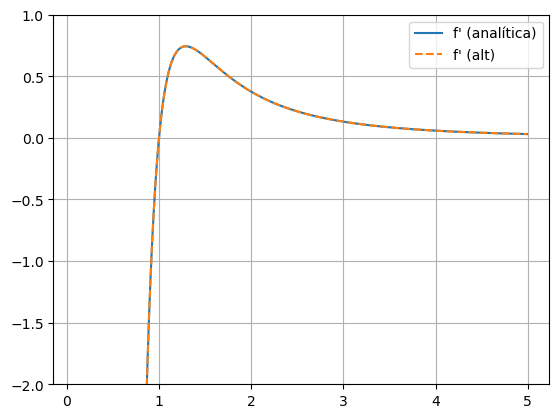

In [38]:
z1 = x**4
z2 = x**2
z_y = 1/x
dy = -4/x**5 + 4/x**3
dz1_num , dz2_num  = deriv_sim(z1,x) , deriv_sim(z2,x)
dzdx = deriv_sim(z_y,x)
dy_alt = (16/dz1_num - 8/dz2_num)*dzdx

plt.plot(x,dy,label=r"f' (analítica)")
plt.plot(x,dy_alt,'--',label=r"f' (alt)")
plt.ylim([-2,1])
plt.grid(),plt.legend()
plt.show()


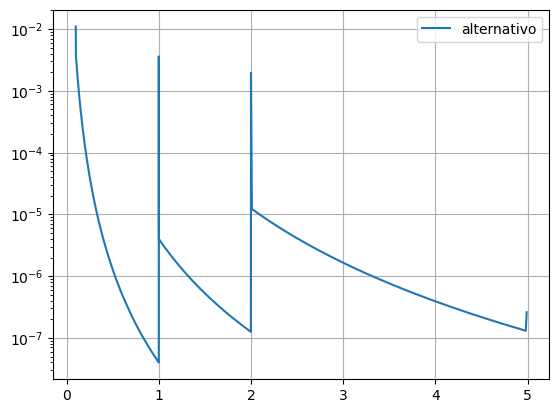

In [39]:
error_alt = abs(dy-dy_alt)
plt.semilogy(x,error_alt,label='alternativo')
plt.grid(),plt.legend()
plt.show()


## Haciendo varias gráficas

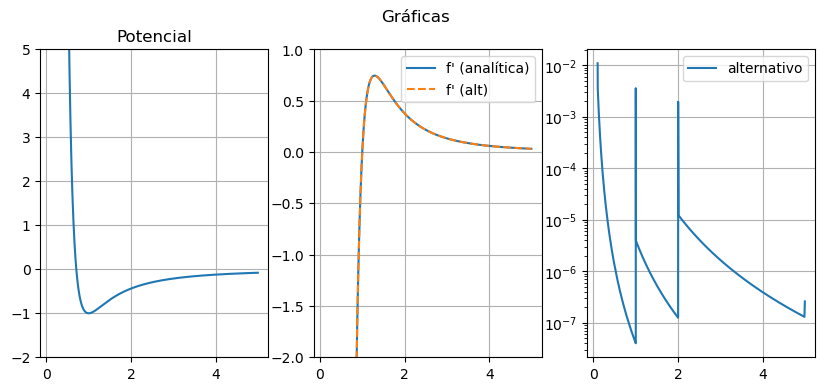

In [50]:
h1 = 1e-4
pt_empalme = 1
pt_empalme_2 = 2
x1 = np.arange(0.1,pt_empalme,h1)
h2 = 1e-3
x2 = np.arange(pt_empalme,pt_empalme_2,h2)
h3 = 1e-2
x3 = np.arange(pt_empalme_2,5,h3)
x = np.concatenate((x1,x2,x3))
y = 1/x**4 - 2/x**2
#
z1 = x**4
z2 = x**2
z_y = 1/x
dy = -4/x**5 + 4/x**3
dz1_num , dz2_num  = deriv_sim(z1,x) , deriv_sim(z2,x)
dzdx = deriv_sim(z_y,x)
dy_alt = (16/dz1_num - 8/dz2_num)*dzdx
#
error_alt = abs(dy-dy_alt)
#

##Gráficas

fig, ejes = plt.subplots(figsize=(10,4),nrows=1, ncols=3) #Me abre una colección de gráficas
fig.suptitle('Gráficas')

#Cómo voy configurando cada gráfica
ejes[0].set_title('Potencial')
ejes[0].plot(x,y)
ejes[0].set_ylim([-2,5])
ejes[0].grid()
#
ejes[1].plot(x,dy,label=r"f' (analítica)")
ejes[1].plot(x,dy_alt,'--',label=r"f' (alt)")
ejes[1].set_ylim([-2,1])
ejes[1].grid(),ejes[1].legend()
#
ejes[2].semilogy(x,error_alt,label='alternativo')
ejes[2].grid(),ejes[2].legend()
#
plt.show()
